<a href="https://colab.research.google.com/github/chin0308/Research_Papers/blob/main/2D_Navier_Stokes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib tensorflow scikit-learn torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

Epoch 0, Loss: 19.065428
Epoch 1000, Loss: 3.921611
Epoch 2000, Loss: 3.027066
Epoch 3000, Loss: 2.192208
Epoch 4000, Loss: 2.021787
Training completed in 2067.33 seconds

Estimated Drag Force: 0.0007 N (Expected ~0.2–0.3 N)


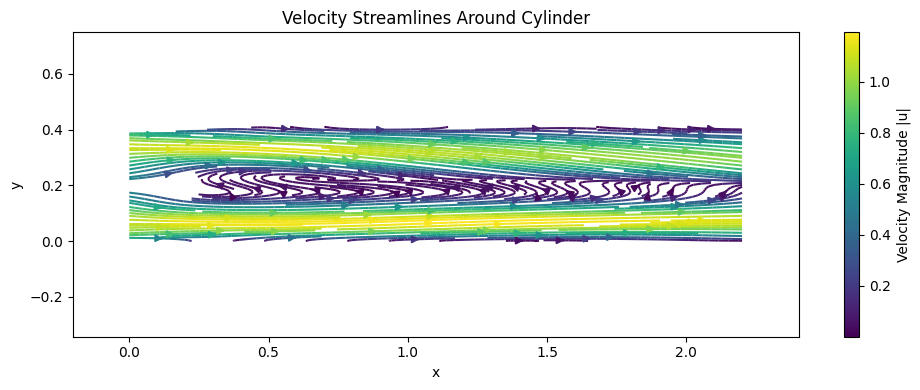

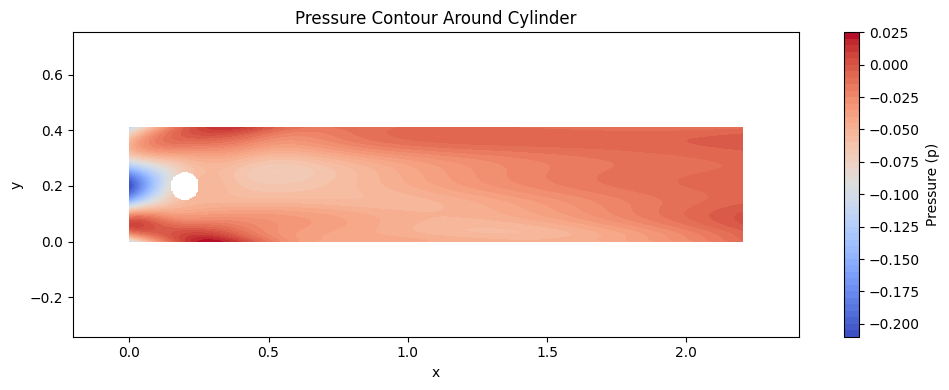

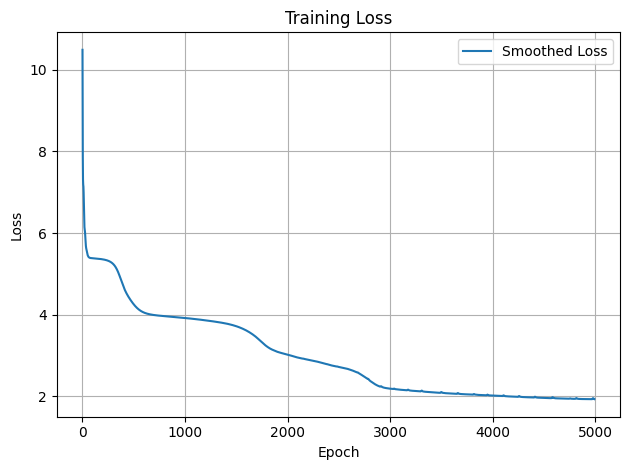

Model saved as 'pinn_cylinder_optimized.h5'


In [1]:

# Import necessary libraries
import numpy as np                      # For numerical operations
import matplotlib.pyplot as plt        # For plotting flow visualizations
import tensorflow as tf                # TensorFlow for deep learning operations
from time import time                  # To record training time

# -----------------------------
# Problem Parameters
# -----------------------------
Re = 100                      # Reynolds number
U = 1.0                       # Inlet velocity magnitude
D = 0.1                       # Characteristic length (cylinder diameter)
rho = 1.0                     # Fluid density
mu = U * D / Re               # Dynamic viscosity from Reynolds number
nu = mu / rho                 # Kinematic viscosity

# -----------------------------
# Geometry Setup
# -----------------------------
r_cyl = 0.05                  # Radius of the cylinder
xc, yc = 0.2, 0.2             # Cylinder center coordinates
R_sq = r_cyl ** 2             # Square of radius for optimization

# Domain bounds
x_min, x_max = 0.0, 2.2
y_min, y_max = 0.0, 0.41

# Sampling parameters
N_f = 20000                  # Number of interior collocation points
N_b = 1000                   # Number of boundary points
nx, ny = 300, 100            # Grid resolution for visualization

# -----------------------------
# Grid Generation and Point Sampling
# -----------------------------
x = np.linspace(x_min, x_max, nx)
y = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(x, y)
XY = np.vstack((X.ravel(), Y.ravel())).T

# Function to detect if a point lies inside the cylinder
def inside_cylinder(pt):
    return np.sum((pt - [xc, yc]) ** 2, axis=1) < R_sq

# Normalization to [0, 1] domain for neural network training stability
def normalize(XY):
    x = (XY[:, 0:1] - x_min) / (x_max - x_min)
    y = (XY[:, 1:2] - y_min) / (y_max - y_min)
    return np.hstack((x, y))

# Apply cylinder mask
mask = ~inside_cylinder(XY)
XY_interior = XY[mask]             # Interior (fluid) points
XY_cylinder = XY[~mask]            # Points on/inside cylinder

# Function to identify boundary points including inlet, outlet, walls, and cylinder
def get_boundary_mask(pt):
    x, y = pt[:, 0], pt[:, 1]
    return (
        (np.abs(x - x_min) < 1e-6) |
        (np.abs(x - x_max) < 1e-6) |
        (np.abs(y - y_min) < 1e-6) |
        (np.abs(y - y_max) < 1e-6) |
        (np.abs(np.sum((pt - [xc, yc]) ** 2, axis=1) - R_sq) < 1e-3)
    )

# Boundary points and masks
XY_boundary = XY[get_boundary_mask(XY)]
x_b, y_b = XY_boundary[:, 0], XY_boundary[:, 1]
inlet_mask = np.isclose(x_b, x_min)
outlet_mask = np.isclose(x_b, x_max)
wall_mask = np.isclose(y_b, y_min) | np.isclose(y_b, y_max)
cylinder_mask = (np.abs(np.sum((XY_boundary - [xc, yc]) ** 2, axis=1) - R_sq) < 1e-3)

# Sample and convert to tensors
XY_f_np = XY_interior[np.random.choice(len(XY_interior), N_f, replace=False)]
XY_f = tf.convert_to_tensor(normalize(XY_f_np), dtype=tf.float32)
XY_b = normalize(XY_boundary)
XY_b_tf = tf.convert_to_tensor(XY_b, dtype=tf.float32)

# Convert masks to TensorFlow boolean tensors
inlet_mask_tf = tf.convert_to_tensor(inlet_mask, dtype=tf.bool)
outlet_mask_tf = tf.convert_to_tensor(outlet_mask, dtype=tf.bool)
wall_mask_tf = tf.convert_to_tensor(wall_mask, dtype=tf.bool)
cylinder_mask_tf = tf.convert_to_tensor(cylinder_mask, dtype=tf.bool)

# Create circular boundary points for drag estimation
theta = np.linspace(0, 2 * np.pi, 200)
cyl_x = xc + r_cyl * np.cos(theta)
cyl_y = yc + r_cyl * np.sin(theta)
cylinder_points = np.vstack((cyl_x, cyl_y)).T
cylinder_tf = tf.convert_to_tensor(normalize(cylinder_points), dtype=tf.float32)

# -----------------------------
# PINN Model Definition
# -----------------------------
def create_pinn_model():
    inputs = tf.keras.Input(shape=(2,))  # x, y inputs
    x = tf.keras.layers.Dense(64, activation='tanh')(inputs)
    x = tf.keras.layers.Dense(64, activation='tanh')(x)
    outputs = tf.keras.layers.Dense(3)(x)  # Output: u, v, p
    return tf.keras.Model(inputs, outputs)

model = create_pinn_model()
tf.config.optimizer.set_jit(True)  # Accelerate with XLA compilation

# -----------------------------
# Physics-Informed Residuals
# -----------------------------
@tf.function
def compute_residuals(XY):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(XY)
        uvp = model(XY)
        u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
        u_grads = tape.gradient(u, XY)
        v_grads = tape.gradient(v, XY)
        p_grads = tape.gradient(p, XY)
        u_x, u_y = u_grads[:, 0:1], u_grads[:, 1:2]
        v_x, v_y = v_grads[:, 0:1], v_grads[:, 1:2]
        p_x, p_y = p_grads[:, 0:1], p_grads[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(XY)
        uvp2 = model(XY)
        u2_grads = tape2.gradient(uvp2[:, 0:1], XY)
        v2_grads = tape2.gradient(uvp2[:, 1:2], XY)
        u_xx = tape2.gradient(u2_grads[:, 0:1], XY)[:, 0:1]
        u_yy = tape2.gradient(u2_grads[:, 1:2], XY)[:, 1:2]
        v_xx = tape2.gradient(v2_grads[:, 0:1], XY)[:, 0:1]
        v_yy = tape2.gradient(v2_grads[:, 1:2], XY)[:, 1:2]

    # Compute Navier–Stokes residuals
    continuity = u_x + v_y
    mom_x = u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    mom_y = u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)
    return continuity, mom_x, mom_y
# -----------------------------
# Loss Computation Function
# -----------------------------
def compute_loss():
    # Compute PDE residual loss
    cont, momx, momy = compute_residuals(XY_f)
    loss_pde = tf.reduce_mean(cont**2) + tf.reduce_mean(momx**2) + tf.reduce_mean(momy**2)

    # Evaluate boundary condition loss
    uvp = model(XY_b_tf)
    u, v, p = tf.split(uvp, 3, axis=1)

    # Loss includes inlet velocity, outlet pressure, no-slip on walls and cylinder
    loss_bc = (
        tf.reduce_mean((u[inlet_mask_tf] - 1.0) ** 2) +
        tf.reduce_mean(v[inlet_mask_tf] ** 2) +
        tf.reduce_mean(p[outlet_mask_tf] ** 2) +
        tf.reduce_mean(u[wall_mask_tf] ** 2 + v[wall_mask_tf] ** 2) +
        tf.reduce_mean(u[cylinder_mask_tf] ** 2 + v[cylinder_mask_tf] ** 2)
    )
    return loss_pde + 10.0 * loss_bc  # Weight boundary loss

# -----------------------------
# Training Configuration
# -----------------------------
optimizer = tf.keras.optimizers.Adam(1e-3)
loss_history = []  # To store training losses

@tf.function
def train_step():
    # Single training step
    with tf.GradientTape() as tape:
        loss = compute_loss()
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# Training loop with early stopping and LR scheduler
start = time()
best_loss, patience, counter = float('inf'), 500, 0
factor, min_lr = 0.5, 1e-5

for epoch in range(5000):
    loss = train_step()
    loss_val = loss.numpy()
    loss_history.append(loss_val)

    # Track best loss and update learning rate
    if loss_val < best_loss - 1e-5:
        best_loss = loss_val
        counter = 0
    else:
        counter += 1

    # Reduce LR if no improvement
    if counter >= patience:
        lr = optimizer.learning_rate.numpy()
        new_lr = max(lr * factor, min_lr)
        optimizer.learning_rate.assign(new_lr)
        counter = 0
        print(f"\\nEpoch {epoch}: Reduced LR to {new_lr:.2e}")

    # Print progress every 1000 epochs
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss_val:.6f}")

    # Stop early if loss threshold is met
    if loss_val < 1e-3:
        print(f"Early stopping at epoch {epoch}, Loss: {loss_val:.6f}")
        break

print(f"Training completed in {time() - start:.2f} seconds")

# -----------------------------
# Drag Force Estimation
# -----------------------------
# Extract pressure values on the cylinder surface
p_vals = model(cylinder_tf)[:, 1].numpy()
d_theta = 2 * np.pi / len(p_vals)
# Approximate drag force by integrating pressure along the surface
drag_force = np.sum(p_vals * np.cos(theta)) * r_cyl * d_theta
print(f"\\nEstimated Drag Force: {drag_force:.4f} N (Expected ~0.2–0.3 N)")

# -----------------------------
# Visualization of Results
# -----------------------------
XY_grid = normalize(XY)
XY_tensor = tf.convert_to_tensor(XY_grid, dtype=tf.float32)
preds = model(XY_tensor).numpy()
u_pred = preds[:, 0].reshape(ny, nx)
v_pred = preds[:, 1].reshape(ny, nx)
p_pred = preds[:, 2].reshape(ny, nx)

# Mask out cylinder region in visualizations
mask_grid = inside_cylinder(XY).reshape(ny, nx)
u_pred[mask_grid] = np.nan
v_pred[mask_grid] = np.nan
p_pred[mask_grid] = np.nan

# Compute velocity magnitude for streamplot coloring
vel_mag = np.sqrt(u_pred**2 + v_pred**2)

# Plot streamlines
plt.figure(figsize=(10, 4))
plt.streamplot(x, y, u_pred, v_pred, density=2, color=vel_mag, cmap='viridis')
plt.colorbar(label="Velocity Magnitude |u|")
plt.title("Velocity Streamlines Around Cylinder")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.tight_layout()
plt.show()

# Plot pressure contours
plt.figure(figsize=(10, 4))
cp = plt.contourf(X, Y, p_pred, levels=50, cmap='coolwarm')
plt.colorbar(cp, label="Pressure (p)")
plt.title("Pressure Contour Around Cylinder")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.tight_layout()
plt.show()

# Plot training loss history
plt.figure()
plt.plot(np.convolve(loss_history, np.ones(10)/10, mode='valid'), label="Smoothed Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Save model for future use
model.save("pinn_cylinder_optimized.h5")
print("Model saved as 'pinn_cylinder_optimized.h5'")
